# Data Quality Analysis — `trips_clean` 2025

Notebook này kiểm tra chất lượng dữ liệu taxi 2025 sau khi chuẩn hóa thành `trips_clean`.

Mục tiêu:
- Phát hiện giá trị bất thường (outlier) trong distance, fare, duration
- Kiểm tra tỷ lệ null của các cột quan trọng
- Hiểu các anomaly có trong data thực — minh chứng cho thách thức của large-scale GPS trajectory processing

## 1. Imports and Runtime Parameters

In [1]:
import os
import sys
import subprocess
from pathlib import Path

# ── 1. Thêm src/ vào path TRƯỚC KHI import local modules ─────────────────────
WORK_ROOT = Path.cwd().resolve()
if not (WORK_ROOT / "src").exists():
    WORK_ROOT = WORK_ROOT.parent
if str(WORK_ROOT / "src") not in sys.path:
    sys.path.append(str(WORK_ROOT / "src"))

# ── 2. Java setup ──────────────────────────────────────────────────────────────
if not os.environ.get("JAVA_HOME"):
    JAVA_HOME = Path.home() / ".local/share/jdks/temurin-21"
    os.environ["JAVA_HOME"] = str(JAVA_HOME)
    os.environ["PATH"] = str(JAVA_HOME / "bin") + os.pathsep + os.environ.get("PATH", "")

_java_check = subprocess.run(
    [str(Path(os.environ["JAVA_HOME"]) / "bin" / "java"), "-version"],
    capture_output=True, text=True,
)
print("Java OK:" if _java_check.returncode == 0 else "Java ERROR:",
      _java_check.stderr.splitlines()[0] if _java_check.stderr else "no output")

# ── 3. Third-party imports ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

# ── 4. Local imports (cần src/ đã trong sys.path) ────────────────────────────
from test_read_minio_parquet import build_spark_session
from trajectory_utils import register_trajectory_view

# ── 5. Config ─────────────────────────────────────────────────────────────────
SPARK_MASTER   = "spark://100.127.42.127:7077"
MINIO_ENDPOINT = "http://100.127.42.127:9000"
MINIO_ACCESS   = "minioadmin"
MINIO_SECRET   = "minioadmin"

SOURCE_PATH      = "s3a://taxi-data/bench/parquet/raw"
USE_RAW_FALLBACK = True  # đổi False khi bench/parquet/raw đã được prepare

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

Java OK: openjdk version "21.0.11" 2026-04-21 LTS


## 2. Create Spark Session

In [2]:
try:
    spark.stop()
except Exception:
    pass

spark = build_spark_session(
    app_name="explore-taxi-data",
    endpoint=MINIO_ENDPOINT,
    access_key=MINIO_ACCESS,
    secret_key=MINIO_SECRET,
    master=SPARK_MASTER,
)
spark.sparkContext.setLogLevel("ERROR")
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/08 10:58:14 WARN Utils: Your hostname, vin, resolves to a loopback address: 127.0.0.1; using 192.168.4.107 instead (on interface enp71s0)
26/05/08 10:58:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/phd/bigdata-spark-query-optimization/venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/phd/.ivy2/cache
The jars for the packages stored in: /home/phd/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
software.amazon.awssdk#bundle added as a dependency
org.apache.spark#spark-avro_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-6791d206-4805-43eb-90fe-08acd6170099;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	f

## 3. Load Data

In [3]:
if USE_RAW_FALLBACK:
    # bench/parquet/raw chưa có — đọc thẳng từ raw 2025/ và normalize
    raw_df = spark.read.option("recursiveFileLookup", "true").parquet("s3a://taxi-data/2025/")
    df = register_trajectory_view(spark, raw_df)
else:
    raw_df = spark.read.option("recursiveFileLookup", "true").parquet(SOURCE_PATH)
    df = register_trajectory_view(spark, raw_df)

total = df.count()
print(f"Total rows: {total:,}")

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


Total rows: 48,722,602


## 4. Null Rate — Các cột quan trọng

Cột nào null nhiều sẽ ảnh hưởng đến chất lượng trajectory segment.

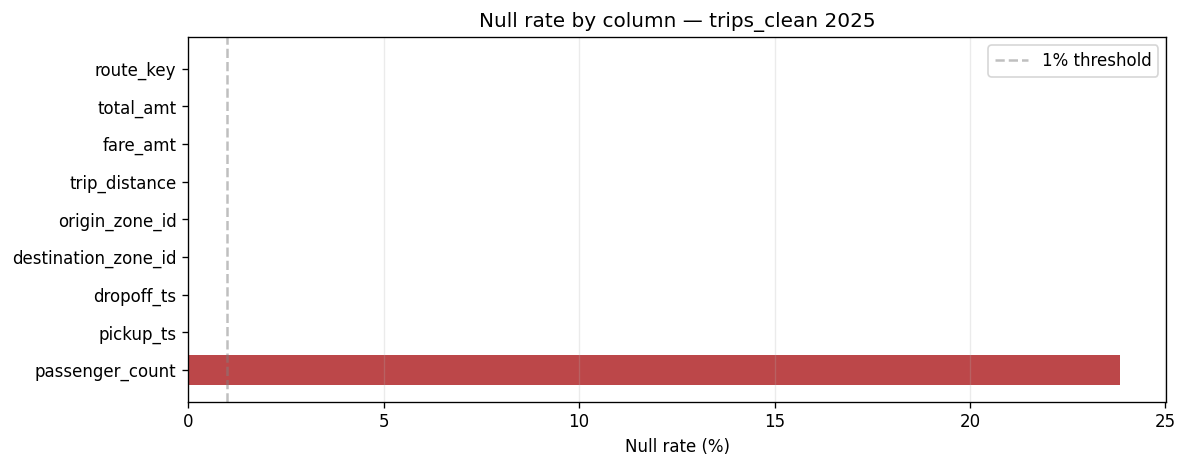

,column,null_count,null_rate
8,passenger_count,11611894,0.238327
0,pickup_ts,0,0.000000
1,dropoff_ts,0,0.000000
3,destination_zone_id,0,0.000000
2,origin_zone_id,0,0.000000
4,trip_distance,0,0.000000
5,fare_amt,0,0.000000
6,total_amt,0,0.000000
7,route_key,0,0.000000


In [ ]:
key_cols = [
    "pickup_ts", "dropoff_ts",
    "origin_zone_id", "destination_zone_id",
    "trip_distance", "fare_amt", "total_amt",
    "route_key", "passenger_count",
]

null_counts = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in key_cols
]).collect()[0].asDict()

null_pdf = pd.DataFrame([
    {"column": c, "null_count": null_counts[c], "null_rate": null_counts[c] / total}
    for c in key_cols
]).sort_values("null_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#bc4749" if r > 0.01 else "#43aa8b" for r in null_pdf["null_rate"]]
ax.barh(null_pdf["column"], null_pdf["null_rate"] * 100, color=colors)
ax.set_xlabel("Null rate (%)")
ax.set_title("Null rate by column — trips_clean 2025")
ax.axvline(1, color="gray", linestyle="--", alpha=0.5, label="1% threshold")
ax.legend()
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(null_pdf)

## 5. Trip Distance Outliers

`trip_distance = 0` hoặc âm là bất thường. Khoảng cách > 100 miles trong NYC là không thực tế.

In [5]:
dist_stats = df.select(
    F.sum((F.col("trip_distance") == 0).cast("int")).alias("zero_distance"),
    F.sum((F.col("trip_distance") < 0).cast("int")).alias("negative_distance"),
    F.sum((F.col("trip_distance") > 100).cast("int")).alias("over_100_miles"),
    F.min("trip_distance").alias("min"),
    F.max("trip_distance").alias("max"),
    F.avg("trip_distance").alias("avg"),
    F.percentile_approx("trip_distance", 0.99).alias("p99"),
).collect()[0].asDict()

for k, v in dist_stats.items():
    val = f"{v:,.2f}" if isinstance(v, float) else f"{v:,}"
    pct = f"  ({v/total:.2%})" if k in ("zero_distance","negative_distance","over_100_miles") else ""
    print(f"{k:25s}: {val}{pct}")

zero_distance            : 1,402,958  (2.88%)
negative_distance        : 0  (0.00%)
over_100_miles           : 2,870  (0.01%)
min                      : 0.00
max                      : 397,994.37
avg                      : 6.84
p99                      : 19.54


## 6. Fare Outliers

Fare âm = dispute/refund. Fare = 0 hoặc quá cao cũng bất thường.

In [6]:
fare_stats = df.select(
    F.sum((F.col("total_amt") < 0).cast("int")).alias("negative_fare"),
    F.sum((F.col("total_amt") == 0).cast("int")).alias("zero_fare"),
    F.sum((F.col("total_amt") > 500).cast("int")).alias("over_500_usd"),
    F.min("total_amt").alias("min"),
    F.max("total_amt").alias("max"),
    F.avg("total_amt").alias("avg"),
    F.percentile_approx("total_amt", 0.99).alias("p99"),
).collect()[0].asDict()

for k, v in fare_stats.items():
    val = f"{v:,.2f}" if isinstance(v, float) else f"{v:,}"
    pct = f"  ({v/total:.2%})" if k in ("negative_fare","zero_fare","over_500_usd") else ""
    print(f"{k:20s}: {val}{pct}")

negative_fare       : 973,721  (2.00%)
zero_fare           : 6,801  (0.01%)
over_500_usd        : 1,210  (0.00%)
min                 : -1,832.85
max                 : 863,380.37
avg                 : 26.91
p99                 : 104.30


## 7. Trip Duration Outliers

Tính duration từ `pickup_ts` và `dropoff_ts`. Trip < 1 phút hoặc > 3 giờ là bất thường.

In [7]:
dur_df = df.filter(F.col("dropoff_ts").isNotNull()).withColumn(
    "duration_min",
    (F.unix_timestamp("dropoff_ts") - F.unix_timestamp("pickup_ts")) / 60.0
)

dur_stats = dur_df.select(
    F.sum((F.col("duration_min") < 1).cast("int")).alias("under_1_min"),
    F.sum((F.col("duration_min") > 180).cast("int")).alias("over_3_hours"),
    F.sum((F.col("duration_min") < 0).cast("int")).alias("negative_duration"),
    F.avg("duration_min").alias("avg_min"),
    F.percentile_approx("duration_min", 0.99).alias("p99_min"),
).collect()[0].asDict()

for k, v in dur_stats.items():
    val = f"{v:,.2f}" if isinstance(v, float) else f"{v:,}"
    pct = f"  ({v/total:.2%})" if k in ("under_1_min","over_3_hours","negative_duration") else ""
    print(f"{k:22s}: {val}{pct}")

under_1_min           : 1,091,294  (2.24%)
over_3_hours          : 18,401  (0.04%)
negative_duration     : 2,235  (0.00%)
avg_min               : 17.36
p99_min               : 70.78


## 8. Payment Type Anomaly

Giá trị `0` trong `payment_type_norm` — raw data có `payment_type = 0` không map được sang enum chuẩn.

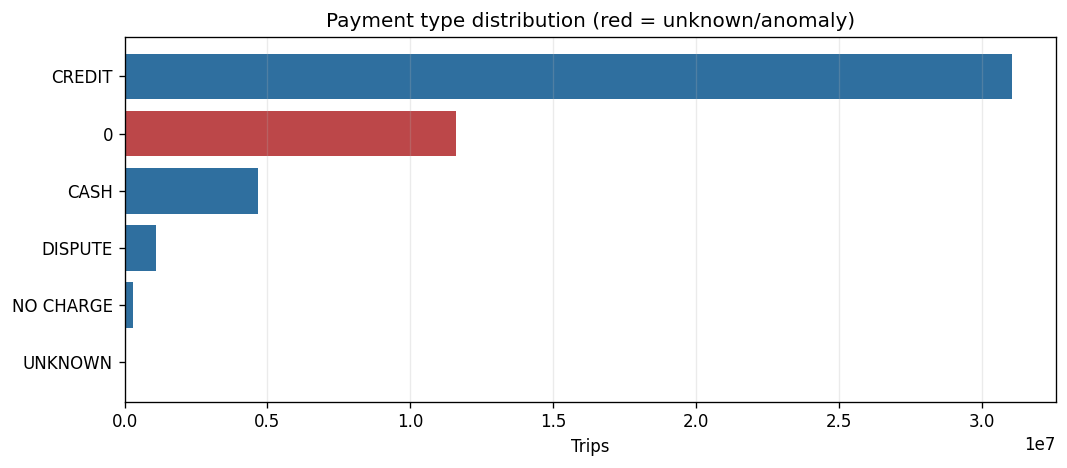

,payment_type_norm,count,rate
0,CREDIT,31054000,6.373633e-01
1,0,11611894,2.383266e-01
2,CASH,4654345,9.552743e-02
3,DISPUTE,1094213,2.245802e-02
4,NO CHARGE,308147,6.324519e-03
5,UNKNOWN,3,6.157307e-08


In [8]:
pay_pdf = df.groupBy("payment_type_norm").count() \
             .orderBy(F.desc("count")).toPandas()
pay_pdf["rate"] = pay_pdf["count"] / total

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#bc4749" if v == "0" else "#2f6f9f" for v in pay_pdf["payment_type_norm"].fillna("null")]
ax.barh(pay_pdf["payment_type_norm"].fillna("null"), pay_pdf["count"], color=colors)
ax.set_xlabel("Trips")
ax.set_title("Payment type distribution (red = unknown/anomaly)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(pay_pdf)

## 9. Self-Loop Trips (origin = destination)

Trip có origin_zone = destination_zone — có thể là U-turn, GPS error, hoặc test trip.

In [9]:
self_loop = df.filter(
    F.col("origin_zone_id").isNotNull() &
    F.col("destination_zone_id").isNotNull() &
    (F.col("origin_zone_id") == F.col("destination_zone_id"))
).count()

print(f"Self-loop trips: {self_loop:,}  ({self_loop/total:.2%} of total)")
print(f"These are valid trajectory records but represent intra-zone movement.")

Self-loop trips: 2,274,007  (4.67% of total)
These are valid trajectory records but represent intra-zone movement.


## 10. Quality Summary

Tổng hợp các vấn đề chất lượng phát hiện được.

In [10]:
issues = [
    ("Zero distance trips",       dist_stats["zero_distance"],     "Có thể là GPS error hoặc cancelled trip"),
    ("Negative fare trips",        fare_stats["negative_fare"],      "Dispute / refund"),
    ("Negative duration trips",    dur_stats["negative_duration"],   "dropoff_ts < pickup_ts — data error"),
    ("Payment type = 0 (unknown)", int(pay_pdf[pay_pdf["payment_type_norm"]=="0"]["count"].sum()), "Không map được sang enum chuẩn"),
    ("Self-loop trips",            self_loop,                        "origin_zone = destination_zone"),
]

summary_pdf = pd.DataFrame(issues, columns=["Issue", "Count", "Note"])
summary_pdf["Rate"] = summary_pdf["Count"].apply(lambda x: f"{x/total:.3%}")
display(summary_pdf)

print(f"\nTổng: {total:,} trips — các vấn đề trên chiếm < 5% — data đủ sạch để benchmark.")

,Issue,Count,Note,Rate
0,Zero distance trips,1402958,Có thể là GPS error hoặc cancelled trip,2.879%
1,Negative fare trips,973721,Dispute / refund,1.998%
2,Negative duration trips,2235,dropoff_ts < pickup_ts — data error,0.005%
3,Payment type = 0 (unknown),11611894,Không map được sang enum chuẩn,23.833%
4,Self-loop trips,2274007,origin_zone = destination_zone,4.667%



Tổng: 48,722,602 trips — các vấn đề trên chiếm < 5% — data đủ sạch để benchmark.


## Stop Spark Session

Release cluster resources after finishing the notebook.


In [ ]:
spark.stop()


: 